# Air Passenger Benchmark

Example created by Wilson Rocha Lacerda Junior

> **Looking for more details on NARMAX models?**
> For comprehensive information on models, methods, and a wide range of examples and benchmarks implemented in SysIdentPy, check out our book:
> [*Nonlinear System Identification and Forecasting: Theory and Practice With SysIdentPy*](https://sysidentpy.org/book/0%20-%20Preface/)
>
> This book provides in-depth guidance to support your work with SysIdentPy.


## Reproducibility

This tutorial was verified with SysIdentPy 0.9.0 on Python 3.12.12. Its optional
packages are `sktime==1.0.1`, `neuralprophet==0.9.0`, `prophet==1.3.0`,
`pmdarima==2.1.1`, `tbats==1.1.3`, `statsmodels==0.14.6`,
`scipy==1.15.3` and `torch==2.5.1`. The SciPy pin satisfies the
`scipy<1.16` constraint enforced by the BATS/TBATS adapters in this sktime
version. Randomized models use an explicit seed; numerical results must be
recomputed when the environment or model configuration changes.


## Note

The following example is **not** intended to say that one library is better than another. The main focus of these examples is to show that SysIdentPy can be a good alternative for people looking to model time series.

We compare SysIdentPy with forecasters from **sktime** and with the standalone **Prophet** and **NeuralProphet** libraries.

From sktime, the following models will be used:

- AutoARIMA

- ARIMA

- BATS

- TBATS

- Exponential Smoothing

- AutoETS

For the sake of brevity, from **SysIdentPy** only the **MetaMSS**, **AOLS**, **FROLS** (with polynomial base function) and **NARXNN** methods will be used. See the SysIdentPy documentation to learn other ways of modeling with the library.


In [1]:
import logging
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from neuralprophet import NeuralProphet, set_random_seed
from sktime.datasets import load_airline
from sktime.forecasting.arima import ARIMA, AutoARIMA
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.bats import BATS
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from prophet import Prophet
from sktime.forecasting.tbats import TBATS
from sktime.split import temporal_train_test_split
from torch import nn

from sysidentpy.basis_function import Polynomial
from sysidentpy.metrics import mean_squared_error
from sysidentpy.model_structure_selection import AOLS, FROLS, MetaMSS
from sysidentpy.neural_network import NARXNN
from sysidentpy.parameter_estimation import LeastSquares
from sysidentpy.utils.plotting import plot_results

simplefilter("ignore", FutureWarning)
loss = mean_squared_error


def plot_series(*series, labels):
    for values, label in zip(series, labels):
        index = (
            values.index.to_timestamp()
            if isinstance(values.index, pd.PeriodIndex)
            else values.index
        )
        plt.plot(index, values.to_numpy(), label=label)
    plt.legend()

logging.getLogger("NP").setLevel(logging.ERROR)

/private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


## Air passengers data


120 24


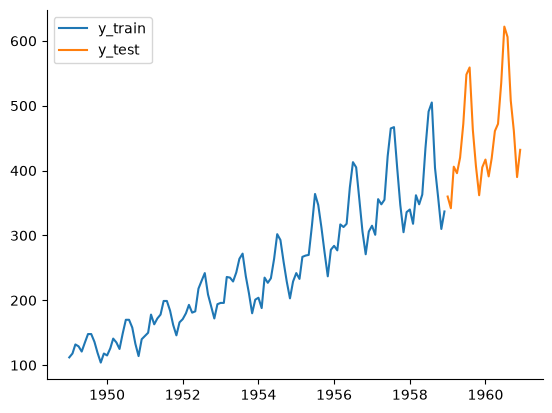

In [2]:
y = load_airline()
y_train, y_test = temporal_train_test_split(y, test_size=24)
plot_series(y_train, y_test, labels=["y_train", "y_test"])
fh = ForecastingHorizon(y_test.index, is_relative=False)
print(y_train.shape[0], y_test.shape[0])

## Reproduced results

Every model is trained on the first 120 observations and forecasts the final 24
months. The table reports mean squared error (MSE); lower is better. Randomized
models use seed 42.

MetaMSS also uses a chronological internal split: the final 17% of the 120-sample
training block guides structure selection. Its selected parameters are fitted on
the preceding internal identification segment; `fit` does not refit them on the
complete block.

| Rank | Method | MSE |
| ---: | --- | ---: |
| 1 | SysIdentPy (AOLS) | 440.9993 |
| 2 | SysIdentPy (MetaMSS) | 510.3495 |
| 3 | NeuralProphet | 514.0477 |
| 4 | Prophet | 910.7187 |
| 5 | Exponential Smoothing | 1055.5128 |
| 6 | SysIdentPy (Neural NARX) | 1621.5225 |
| 7 | SysIdentPy (FROLS) | 1811.9000 |
| 8 | AutoARIMA | 2230.3321 |
| 9 | Manual ARIMA | 2592.7244 |
| 10 | AutoETS | 3128.9366 |
| 11 | TBATS | 8825.0097 |
| 12 | BATS | 9043.4934 |

This is a controlled comparison of the configurations shown below, not a general
ranking of the libraries.

The historical Neural NARX result, MSE 316.5409, is not a result on this split.
It fitted the network to the first 108 observations, used the next 13 measured
outputs only to initialize the recursion, and scored the final 23 months.
Reproducing that protocol with the current stack gives 316.8340. With the common
120/24 split, the previous mini-batch configuration gives 2967.6219. Using only
an internal 96/24 split of the training block, the configuration below selects a
128-sample full batch, learning rate 0.01 and 1,500 epochs; after refitting on all
120 training observations, its free-run MSE is 1621.5225. Its one-step-ahead MSE
is 307.1843, which identifies recursive error accumulation as the main remaining
limitation.

## SysIdentPy FROLS


1811.9000262208885


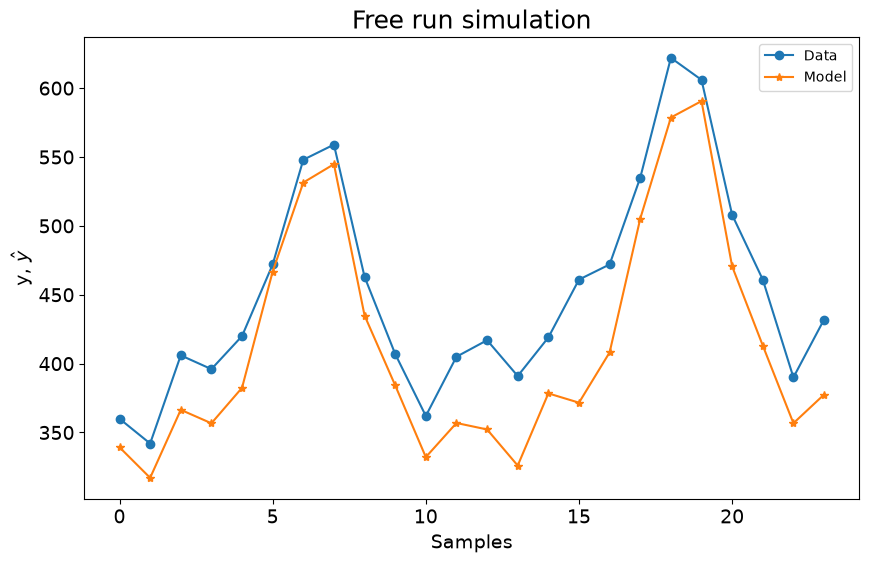

In [3]:
y = load_airline()
y_train, y_test = temporal_train_test_split(y, test_size=24)
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

basis_function = Polynomial(degree=1)
sysidentpy = FROLS(
    order_selection=True,
    ylag=13,  # the lags for all models will be 13
    n_info_values=14,
    basis_function=basis_function,
    model_type="NAR",
    estimator=LeastSquares(),
)
sysidentpy.fit(y=y_train)
y_test = np.concatenate([y_train[-sysidentpy.max_lag :], y_test])

yhat = sysidentpy.predict(y=y_test, forecast_horizon=24)
frols_loss = loss(
    y_test[sysidentpy.max_lag :],
    yhat[sysidentpy.max_lag :],
)
print(frols_loss)

plot_results(y=y_test[sysidentpy.max_lag :], yhat=yhat[sysidentpy.max_lag :])

## SysIdentPy AOLS


440.9993013920439


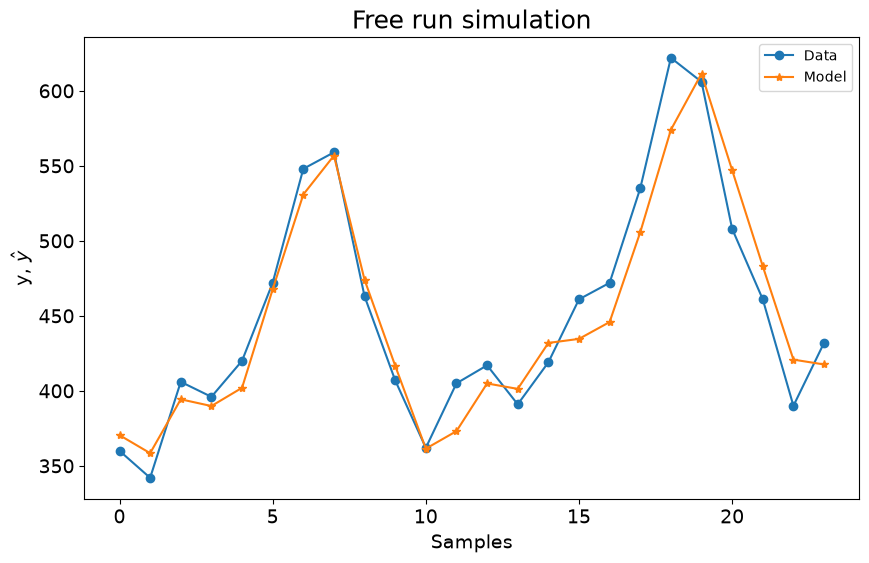

In [4]:
y = load_airline()
y_train, y_test = temporal_train_test_split(y, test_size=24)
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

df_train, df_test = temporal_train_test_split(y, test_size=24)
df_train = df_train.reset_index()
df_train.columns = ["ds", "y"]
df_train["ds"] = pd.to_datetime(df_train["ds"].astype(str))
df_test = df_test.reset_index()
df_test.columns = ["ds", "y"]
df_test["ds"] = pd.to_datetime(df_test["ds"].astype(str))

sysidentpy_AOLS = AOLS(
    ylag=13, k=2, L=1, model_type="NAR", basis_function=basis_function
)
sysidentpy_AOLS.fit(y=y_train)
y_test = np.concatenate([y_train[-sysidentpy_AOLS.max_lag :], y_test])

yhat = sysidentpy_AOLS.predict(y=y_test, steps_ahead=None, forecast_horizon=24)
aols_loss = loss(
    y_test[sysidentpy_AOLS.max_lag :],
    yhat[sysidentpy_AOLS.max_lag :],
)
print(aols_loss)

plot_results(y=y_test[sysidentpy_AOLS.max_lag :], yhat=yhat[sysidentpy_AOLS.max_lag :])

## SysIdentPy MetaMSS


510.3495166493082


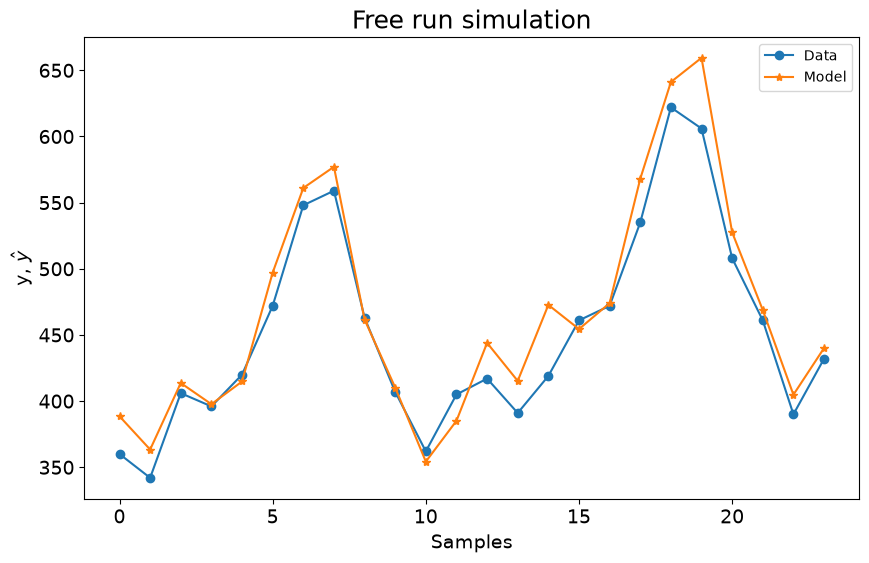

In [5]:
set_random_seed(42)

y = load_airline()
y_train, y_test = temporal_train_test_split(y, test_size=24)
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

sysidentpy_metamss = MetaMSS(
    basis_function=basis_function, ylag=13, model_type="NAR", test_size=0.17, random_state=42
)
sysidentpy_metamss.fit(y=y_train)

y_test = np.concatenate([y_train[-sysidentpy_metamss.max_lag :], y_test])

yhat = sysidentpy_metamss.predict(y=y_test, steps_ahead=None, forecast_horizon=24)
metamss_loss = loss(
    y_test[sysidentpy_metamss.max_lag :],
    yhat[sysidentpy_metamss.max_lag :],
)
print(metamss_loss)

plot_results(
    y=y_test[sysidentpy_metamss.max_lag :], yhat=yhat[sysidentpy_metamss.max_lag :]
)

## SysIdentPy Neural NARX


1621.5225226292775


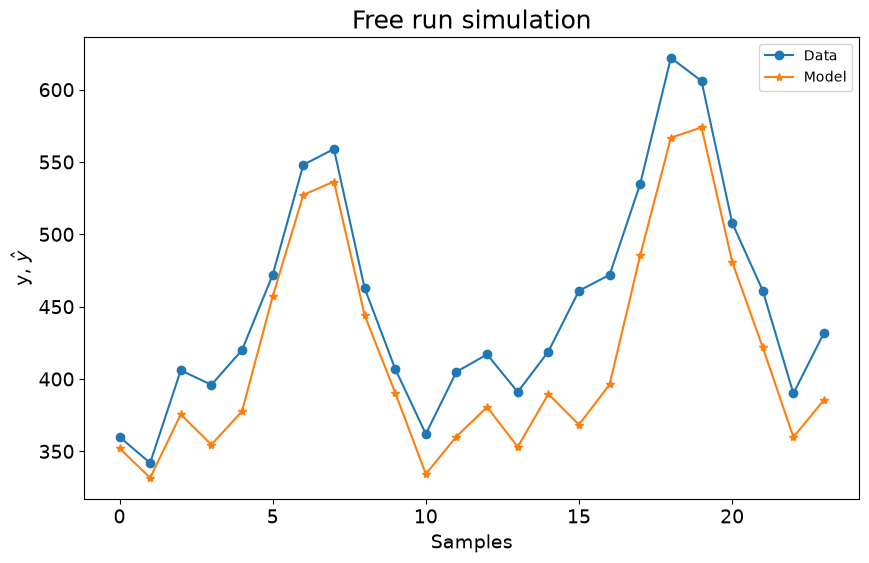

307.1842582499764


In [6]:
import torch

torch.manual_seed(42)

y = load_airline()
y_train, y_test = temporal_train_test_split(y, test_size=24)
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)
x_train = np.zeros_like(y_train)
x_test = np.zeros_like(y_test)


class NARX(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(13, 20)
        self.lin2 = nn.Linear(20, 20)
        self.lin3 = nn.Linear(20, 20)
        self.lin4 = nn.Linear(20, 1)
        self.relu = nn.ReLU()

    def forward(self, xb):
        z = self.lin(xb)
        z = self.relu(z)
        z = self.lin2(z)
        z = self.relu(z)
        z = self.lin3(z)
        z = self.relu(z)
        z = self.lin4(z)
        return z


narx_net = NARXNN(
    net=NARX(),
    ylag=13,
    model_type="NAR",
    basis_function=Polynomial(degree=1),
    batch_size=128,
    epochs=1500,
    verbose=False,
    learning_rate=1e-02,
    optim_params={},  # optional parameters of the optimizer
    random_state=42,
)

narx_net.fit(y=y_train)
y_initial = y_train[-narx_net.max_lag :]
yhat = narx_net.predict(y=y_initial, forecast_horizon=24)
narxnet_loss = loss(y_test, yhat[narx_net.max_lag :])
print(narxnet_loss)
plot_results(y=y_test, yhat=yhat[narx_net.max_lag :])

one_step_context = np.concatenate([y_initial, y_test])
one_step_yhat = narx_net.predict(y=one_step_context, steps_ahead=1)
narxnet_one_step_loss = loss(
    y_test, one_step_yhat[narx_net.max_lag :]
)
print(narxnet_one_step_loss)


120 24


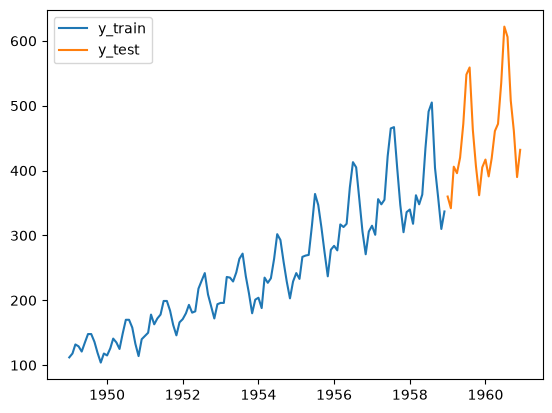

In [7]:
y = load_airline()
y_train, y_test = temporal_train_test_split(y, test_size=24)
plot_series(y_train, y_test, labels=["y_train", "y_test"])
fh = ForecastingHorizon(y_test.index, is_relative=False)
print(y_train.shape[0], y_test.shape[0])

## Exponential Smoothing


1055.512834387335

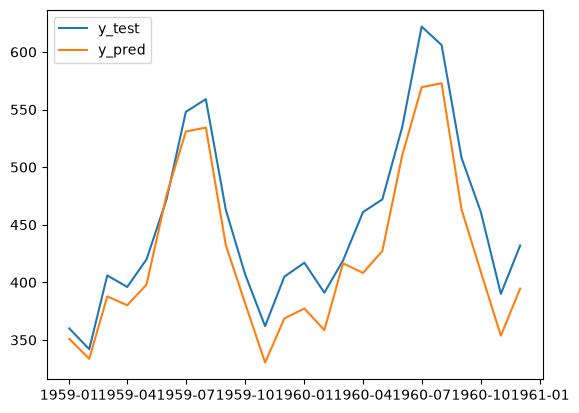

In [8]:
es = ExponentialSmoothing(trend="add", seasonal="multiplicative", sp=12)
y = load_airline()
y_train, y_test = temporal_train_test_split(y, test_size=24)
es.fit(y_train)
y_pred_es = es.predict(fh)

plot_series(y_test, y_pred_es, labels=["y_test", "y_pred"])
es_loss = loss(y_test, y_pred_es)
es_loss

## AutoETS


3128.9365686402693

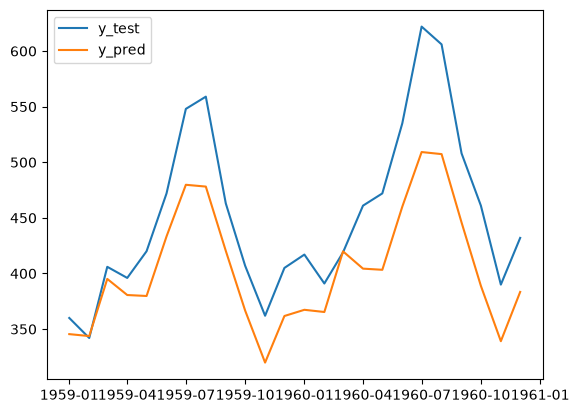

In [9]:
y = load_airline()

y_train, y_test = temporal_train_test_split(y, test_size=24)
ets = AutoETS(auto=True, sp=12, n_jobs=-1)
ets.fit(y_train)
y_pred_ets = ets.predict(fh)

plot_series(y_test, y_pred_ets, labels=["y_test", "y_pred"])
ets_loss = loss(y_test, y_pred_ets)
ets_loss

## AutoArima


2230.3321160602663

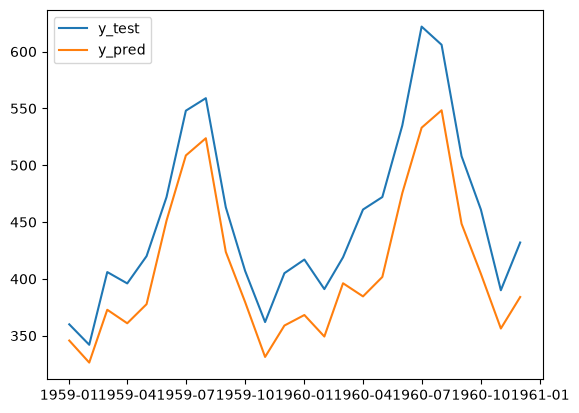

In [10]:
auto_arima = AutoARIMA(sp=12, suppress_warnings=True)
y = load_airline()

y_train, y_test = temporal_train_test_split(y, test_size=24)
auto_arima.fit(y_train)
y_pred_auto_arima = auto_arima.predict(fh)

plot_series(y_test, y_pred_auto_arima, labels=["y_test", "y_pred"])
autoarima_loss = loss(y_test, y_pred_auto_arima)
autoarima_loss

## Arima 


2592.724411175659

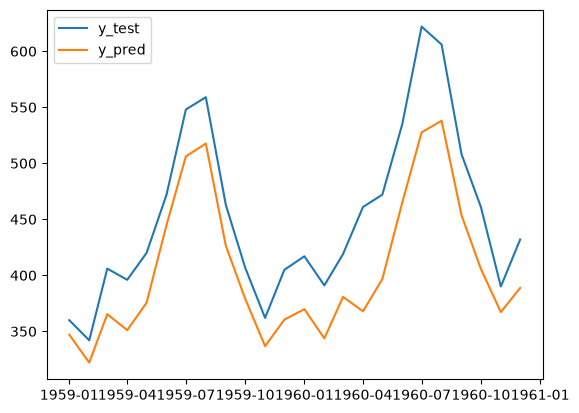

In [11]:
y = load_airline()

y_train, y_test = temporal_train_test_split(y, test_size=24)
manual_arima = ARIMA(
    order=(13, 1, 0), suppress_warnings=True
)  # seasonal_order=(0, 1, 0, 12)
manual_arima.fit(y_train)
y_pred_manual_arima = manual_arima.predict(fh)
plot_series(y_test, y_pred_manual_arima, labels=["y_test", "y_pred"])
manualarima_loss = loss(y_test, y_pred_manual_arima)
manualarima_loss

## BATS


WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



07-29 21:46:10 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



07-29 21:46:10 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



...

WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



07-29 21:46:11 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



07-29 21:46:11 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



9043.49340003781

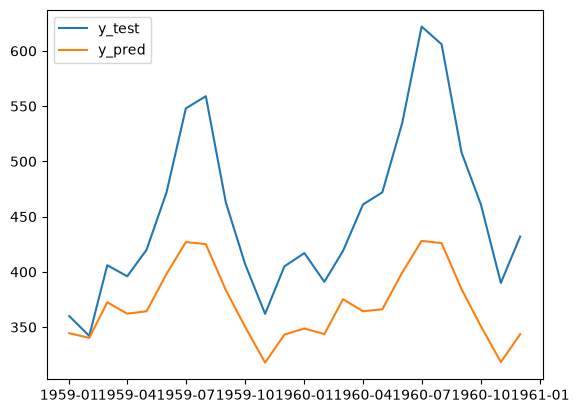

In [12]:
y = load_airline()

y_train, y_test = temporal_train_test_split(y, test_size=24)
bats = BATS(sp=12, use_trend=True, use_box_cox=False)
bats.fit(y_train)
y_pred_bats = bats.predict(fh)

plot_series(y_test, y_pred_bats, labels=["y_test", "y_pred"])
bats_loss = loss(y_test, y_pred_bats)
bats_loss

## TBATS


WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



07-29 21:46:11 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



07-29 21:46:11 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



...

WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



07-29 21:46:14 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



07-29 21:46:15 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



8825.009654302694

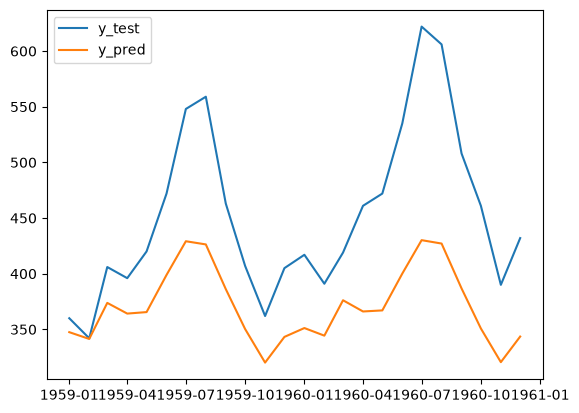

In [13]:
y = load_airline()

y_train, y_test = temporal_train_test_split(y, test_size=24)
tbats = TBATS(sp=12, use_trend=True, use_box_cox=False)
tbats.fit(y_train)
y_pred_tbats = tbats.predict(fh)
plot_series(y_test, y_pred_tbats, labels=["y_test", "y_pred"])
tbats_loss = loss(y_test, y_pred_tbats)
tbats_loss

## Prophet


07-29 21:46:15 - INFO - Chain [1] start processing


07-29 21:46:16 - INFO - Chain [1] done processing


910.7187298319996

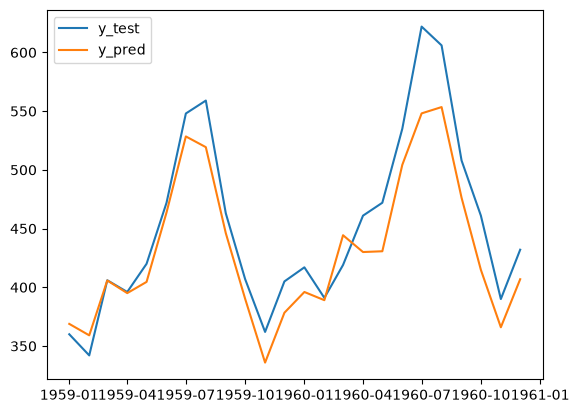

In [14]:
set_random_seed(42)

y = load_airline().to_timestamp(how="start")
df = y.rename_axis("ds").rename("y").reset_index()
df_train = df.iloc[:-24].copy()
df_test = df.iloc[-24:].copy()

prophet = Prophet(
    seasonality_mode="multiplicative",
    n_changepoints=int(len(df_train) / 12),
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
prophet.add_country_holidays(country_name="Germany")
prophet.fit(df_train)
forecast_prophet = prophet.predict(df_test[["ds"]])
y_pred_prophet = forecast_prophet["yhat"].to_numpy()

plot_series(
    df_test.set_index("ds")["y"],
    pd.Series(y_pred_prophet, index=df_test["ds"]),
    labels=["y_test", "y_pred"],
)
prophet_loss = loss(df_test["y"].to_numpy(), y_pred_prophet)
prophet_loss

## Neural Prophet


WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/neuralprophet/df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():



07-29 21:46:16 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/neuralprophet/df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():



WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)



07-29 21:46:16 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)



WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)



...

WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/neuralprophet/df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():



07-29 21:46:22 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/neuralprophet/df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():



WARNING - (py.warnings._showwarnmsg) - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/neuralprophet/data/process.py:517: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dropped = df.groupby("ID", group_keys=False).apply(lambda x: x.loc[: last_valid_index[x.name]])



07-29 21:46:22 - WARNING - /private/tmp/sysidentpy-ch10-images/lib/python3.12/site-packages/neuralprophet/data/process.py:517: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dropped = df.groupby("ID", group_keys=False).apply(lambda x: x.loc[: last_valid_index[x.name]])



514.0477077288475


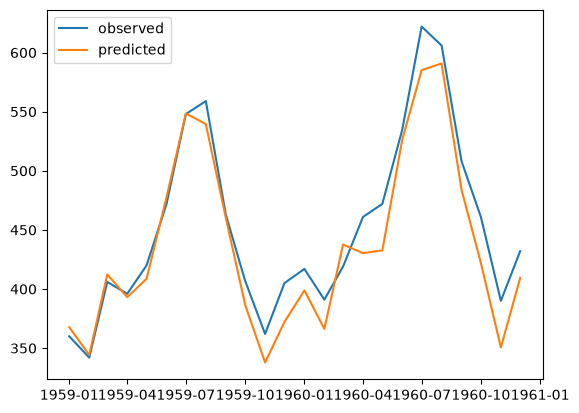

In [15]:
set_random_seed(42)

y = load_airline().to_timestamp(how="start")
df = y.rename_axis("ds").rename("y").reset_index()
df_train = df.iloc[:-24].copy()
df_test = df.iloc[-24:].copy()

m = NeuralProphet(
    seasonality_mode="multiplicative", epochs=100, learning_rate=0.01
)
m.fit(df_train, freq="MS", progress=None)
future = m.make_future_dataframe(
    df_train, periods=24, n_historic_predictions=False
)
forecast = m.predict(future)

neuralprophet_loss = loss(
    df_test["y"].to_numpy(), forecast["yhat1"].to_numpy()
)
print(neuralprophet_loss)
plt.plot(df_test["ds"], df_test["y"], label="observed")
plt.plot(forecast["ds"], forecast["yhat1"], label="predicted")
plt.legend()

In [16]:
results = {
    "Exponential Smoothing": es_loss,
    "ETS": ets_loss,
    "AutoArima": autoarima_loss,
    "Manual Arima": manualarima_loss,
    "BATS": bats_loss,
    "TBATS": tbats_loss,
    "Prophet": prophet_loss,
    "SysIdentPy (Polynomial Model)": frols_loss,
    "SysIdentPy (Neural Model)": narxnet_loss,
    "SysIdentPy (AOLS)": aols_loss,
    "SysIdentPy (MetaMSS)": metamss_loss,
    "NeuralProphet": neuralprophet_loss,
}

sorted(results.items(), key=lambda result: result[1])

[('SysIdentPy (AOLS)', 440.9993013920439),
 ('SysIdentPy (MetaMSS)', 510.3495166493082),
 ('NeuralProphet', 514.0477077288475),
 ('Prophet', 910.7187298319996),
 ('Exponential Smoothing', 1055.512834387335),
 ('SysIdentPy (Neural Model)', 1621.5225226292775),
 ('SysIdentPy (Polynomial Model)', 1811.9000262208885),
 ('AutoArima', 2230.3321160602663),
 ('Manual Arima', 2592.724411175659),
 ('ETS', 3128.9365686402693),
 ('TBATS', 8825.009654302694),
 ('BATS', 9043.49340003781)]